In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
print("All libraries are loaded successfully!")

All libraries are loaded successfully!


In [2]:
df = pd.read_csv(r"C:\Users\KARAN\OneDrive\Desktop\superstore-sales-analysis\data\Sample - Superstore.csv", encoding = 'latin1')
print("Shape:",df.shape)
df.head()

Shape: (9994, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [3]:
print("Dataset Info:")
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quant

C:\Users\KARAN\AppData\Local\Temp\ipykernel_22460\1780610804.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_sales.index, y=category_sales.values, palette="viridis")


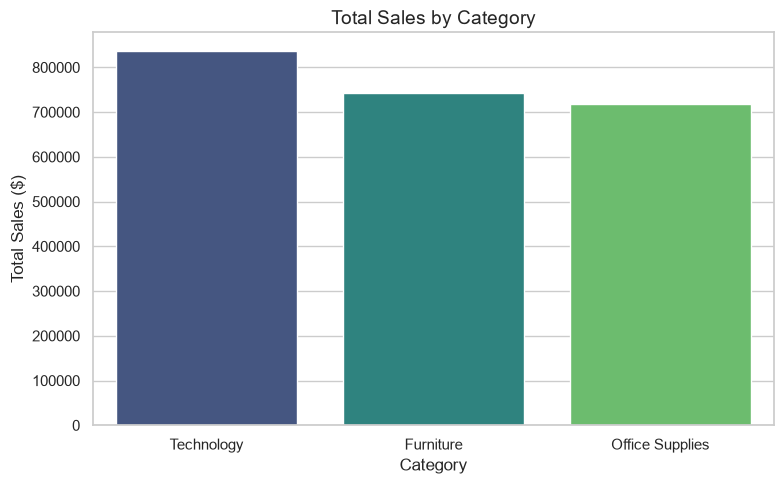

In [4]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=category_sales.index, y=category_sales.values, palette="viridis")
plt.title("Total Sales by Category", fontsize = 14)
plt.xlabel("Category")
plt.ylabel("Total Sales ($)")
plt.tight_layout()
plt.savefig("sales_by_category.png")
plt.show()

C:\Users\KARAN\AppData\Local\Temp\ipykernel_22460\1756380295.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_sales.index, y=category_sales.values, palette="coolwarm")


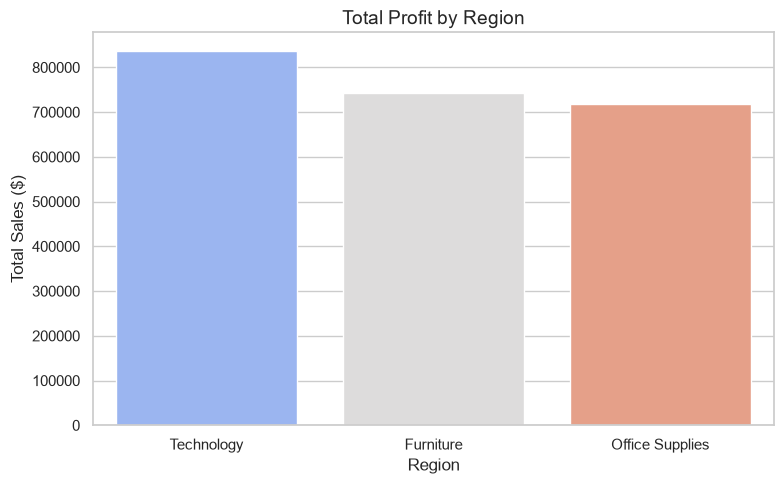

In [5]:
region_profit = df.groupby('Region')['Profit'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=category_sales.index, y=category_sales.values, palette="coolwarm")
plt.title("Total Profit by Region", fontsize = 14)
plt.xlabel("Region")
plt.ylabel("Total Sales ($)")
plt.tight_layout()
plt.savefig("Profit_by_region.png")
plt.show()

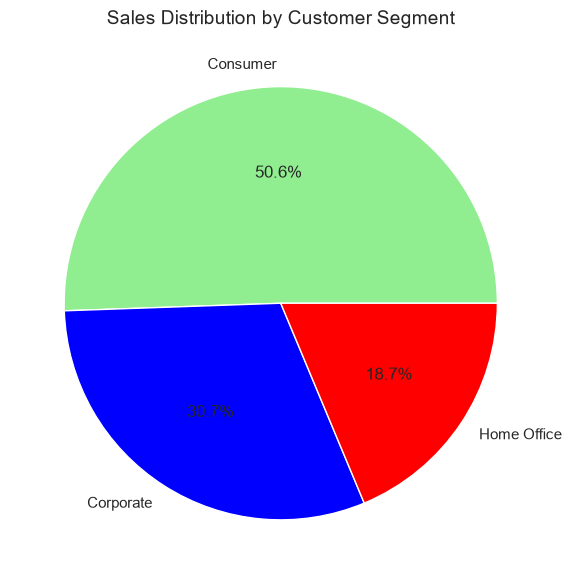

In [6]:
segment_sales = df.groupby('Segment')['Sales'].sum()

plt.figure(figsize=(6,6))
plt.pie(segment_sales, labels=segment_sales.index,autopct = '%1.1f%%', colors=['lightgreen','blue','red'])
plt.title('Sales Distribution by Customer Segment', fontsize = 14)
plt.tight_layout()
plt.savefig("sales_by_segment.png")
plt.show()

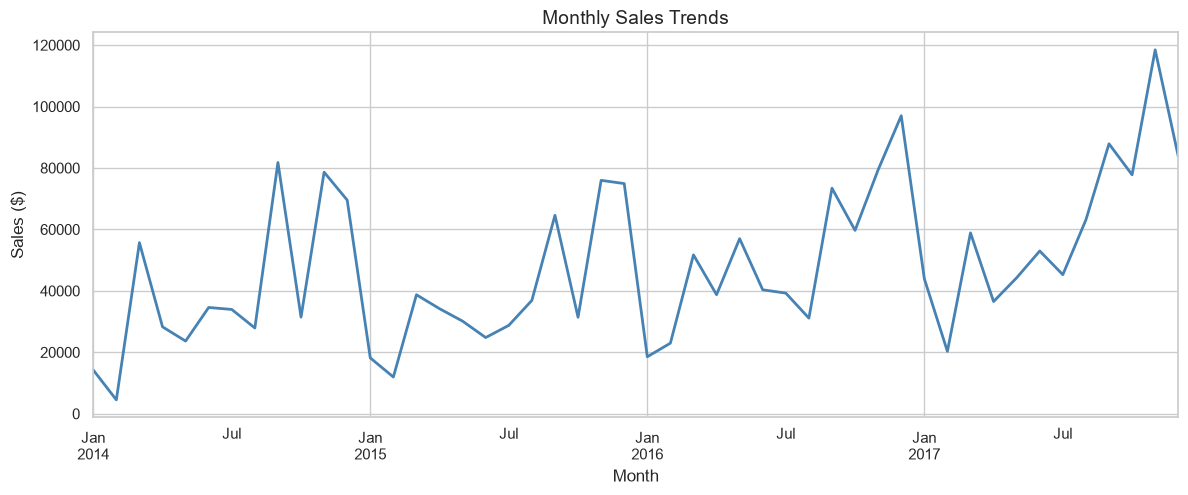

In [7]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Month-Year'] = df["Order Date"].dt.to_period('M')
monthly_sales = df.groupby('Month-Year')['Sales'].sum()

plt.figure(figsize=(14,5))
monthly_sales.plot(kind='line',color='steelblue', linewidth=2)
plt.title('Monthly Sales Trends', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Sales ($)')
plt.savefig('monthly_trends.png')
plt.show()

C:\Users\KARAN\AppData\Local\Temp\ipykernel_22460\1986847123.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products.values, y=top_products.index, palette='magma')


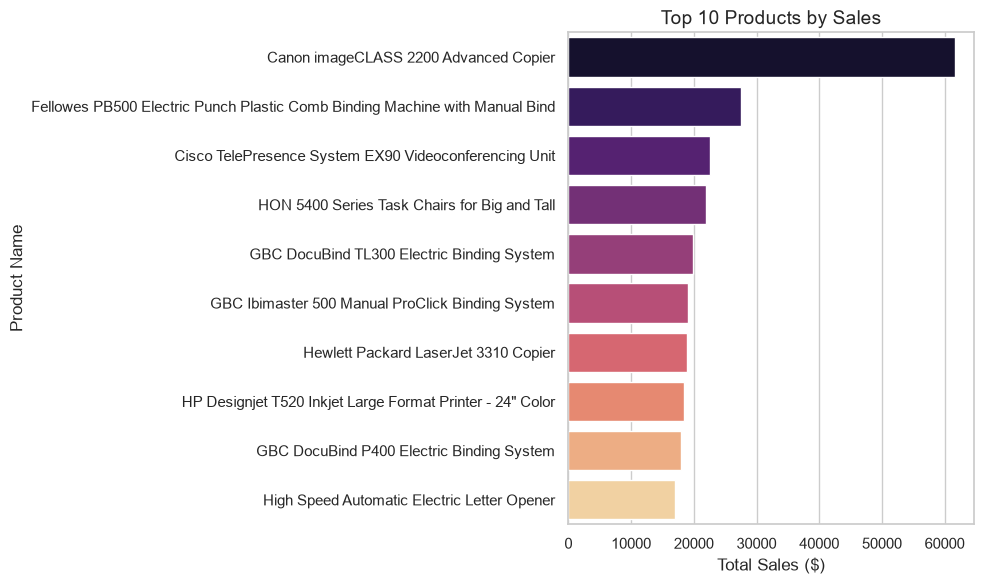

In [8]:
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_products.values, y=top_products.index, palette='magma')
plt.title('Top 10 Products by Sales', fontsize=14)
plt.xlabel('Total Sales ($)')
plt.tight_layout()
plt.savefig('top_products.png')
plt.show()